In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [3]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [4]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


In [5]:
nkn

NameError: name 'nkn' is not defined

In [ ]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 23 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   _RFHYPE6   438693 non-null  float64
 1   TOLDHI3    377857 non-null  float64
 2   _CHOLCH3   438693 non-null  float64
 3   _BMI5CAT   391841 non-null  float64
 4   SMOKE100   417461 non-null  float64
 5   CVDSTRK3   438691 non-null  float64
 6   _MICHD     434058 non-null  float64
 7   _TOTINDA   438693 non-null  float64
 8   _FRTLT1A   438693 non-null  float64
 9   _VEGLT1A   438693 non-null  float64
 10  _DRNKWK1   438693 non-null  float64
 11  _HLTHPLN   438693 non-null  float64
 12  MEDCOST1   438688 non-null  float64
 13  GENHLTH    438689 non-null  float64
 14  MENTHLTH   438691 non-null  float64
 15  PHYSHLTH   438690 non-null  float64
 16  DIFFWALK   420684 non-null  float64
 17  _SEX       438693 non-null  float64
 18  _AGEG5YR   438693 non-null  float64
 19  EDUCA      438688 non-n

In [ ]:
data_final.isna().sum()

_RFHYPE6         0
TOLDHI3      60836
_CHOLCH3         0
_BMI5CAT     46852
SMOKE100     21232
CVDSTRK3         2
_MICHD        4635
_TOTINDA         0
_FRTLT1A         0
_VEGLT1A         0
_DRNKWK1         0
_HLTHPLN         0
MEDCOST1         5
GENHLTH          4
MENTHLTH         2
PHYSHLTH         3
DIFFWALK     18009
_SEX             0
_AGEG5YR         0
EDUCA            5
INCOME3       8847
DIABETE4         3
CVD_LABEL        0
dtype: int64

In [ ]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_final['CVD_SEVERITY'] = data_final['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_final['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [ ]:
data_final.isnull().sum()

_RFHYPE6            0
TOLDHI3         60836
_CHOLCH3            0
_BMI5CAT        46852
SMOKE100        21232
CVDSTRK3            2
_MICHD           4635
_TOTINDA            0
_FRTLT1A            0
_VEGLT1A            0
_DRNKWK1            0
_HLTHPLN            0
MEDCOST1            5
GENHLTH             4
MENTHLTH            2
PHYSHLTH            3
DIFFWALK        18009
_SEX                0
_AGEG5YR            0
EDUCA               5
INCOME3          8847
DIABETE4            3
CVD_LABEL           0
CVD_SEVERITY        0
dtype: int64

In [ ]:
data_final

,_RFHYPE6,TOLDHI3,_CHOLCH3,_BMI5CAT,SMOKE100,CVDSTRK3,_MICHD,_TOTINDA,_FRTLT1A,_VEGLT1A,...,MENTHLTH,PHYSHLTH,DIFFWALK,_SEX,_AGEG5YR,EDUCA,INCOME3,DIABETE4,CVD_LABEL,CVD_SEVERITY
0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,...,10.0,20.0,2.0,2.0,11.0,4.0,5.0,3.0,Healt,0
1,2.0,1.0,1.0,NaN,2.0,2.0,1.0,1.0,1.0,1.0,...,88.0,88.0,1.0,2.0,10.0,6.0,77.0,1.0,CHD Only,1
2,2.0,2.0,1.0,3.0,2.0,2.0,1.0,2.0,1.0,2.0,...,88.0,88.0,2.0,2.0,11.0,4.0,3.0,1.0,CHD Only,1
3,2.0,1.0,1.0,4.0,2.0,2.0,2.0,1.0,1.0,1.0,...,10.0,88.0,2.0,2.0,9.0,4.0,7.0,1.0,Healt,0
4,1.0,1.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,...,88.0,30.0,1.0,1.0,12.0,3.0,4.0,1.0,MI + Stroke,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,...,20.0,88.0,2.0,2.0,3.0,4.0,5.0,2.0,Healt,0
438689,2.0,2.0,1.0,NaN,2.0,2.0,2.0,2.0,1.0,1.0,...,88.0,88.0,2.0,1.0,13.0,4.0,1.0,1.0,Healt,0
438690,1.0,1.0,1.0,4.0,2.0,2.0,2.0,1.0,1.0,1.0,...,88.0,88.0,2.0,1.0,7.0,6.0,10.0,3.0,Healt,0
438691,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,...,88.0,88.0,2.0,1.0,10.0,4.0,6.0,3.0,Healt,0


In [ ]:
data_final = data_final.drop(columns=['TOLDHI3','_MICHD','CVDSTRK3','CVD_LABEL'])
data_final

,_RFHYPE6,_CHOLCH3,_BMI5CAT,SMOKE100,_TOTINDA,_FRTLT1A,_VEGLT1A,_DRNKWK1,_HLTHPLN,MEDCOST1,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,_SEX,_AGEG5YR,EDUCA,INCOME3,DIABETE4,CVD_SEVERITY
0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,5.397605e-79,1.0,2.0,5.0,10.0,20.0,2.0,2.0,11.0,4.0,5.0,3.0,0
1,2.0,1.0,NaN,2.0,1.0,1.0,1.0,5.397605e-79,1.0,2.0,3.0,88.0,88.0,1.0,2.0,10.0,6.0,77.0,1.0,1
2,2.0,1.0,3.0,2.0,2.0,1.0,2.0,5.397605e-79,1.0,2.0,2.0,88.0,88.0,2.0,2.0,11.0,4.0,3.0,1.0,1
3,2.0,1.0,4.0,2.0,1.0,1.0,1.0,3.000000e+02,1.0,2.0,2.0,10.0,88.0,2.0,2.0,9.0,4.0,7.0,1.0,0
4,1.0,1.0,3.0,2.0,1.0,1.0,1.0,5.397605e-79,1.0,2.0,5.0,88.0,30.0,1.0,1.0,12.0,3.0,4.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.870000e+02,2.0,1.0,2.0,20.0,88.0,2.0,2.0,3.0,4.0,5.0,2.0,0
438689,2.0,1.0,NaN,2.0,2.0,1.0,1.0,5.397605e-79,9.0,2.0,3.0,88.0,88.0,2.0,1.0,13.0,4.0,1.0,1.0,0
438690,1.0,1.0,4.0,2.0,1.0,1.0,1.0,4.670000e+02,1.0,2.0,2.0,88.0,88.0,2.0,1.0,7.0,6.0,10.0,3.0,0
438691,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.400000e+02,1.0,2.0,2.0,88.0,88.0,2.0,1.0,10.0,4.0,6.0,3.0,0


In [ ]:
data_new = data_final.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 385391 baris
Terhapus: 53302 baris


In [ ]:
X = data_new.drop(columns=['CVD_SEVERITY'])
y = data_new['CVD_SEVERITY']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Pilih salah satu scaler sesuai kebutuhan
# 2. MinMaxScaler - range [0,1] (cocok untuk data tanpa outlier)
scaler = MinMaxScaler()
# ── SETELAH SCALING, simpan nama kolom ───────────────────────────────────────
feature_names = X_train.columns.tolist()  # simpan SEBELUM scaling

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Konversi kembali ke DataFrame agar nama kolom tetap ada
import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names)



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import numpy as np


def train_evaluate_xgb(X_train, X_test, y_train, y_test,
                        n_estimators=300, max_depth=6, learning_rate=0.1,
                        label_names=('Sehat', 'CVD')):
    """
    Train XGBClassifier dengan class_weight='balanced' dan evaluasi lengkap.

    Parameters
    ----------
    X_train, X_test : array-like  — fitur train/test
    y_train, y_test : array-like  — label train/test (binary 0/1)
    n_estimators    : int         — jumlah pohon (default 300)
    max_depth       : int         — kedalaman pohon (default 6)
    learning_rate   : float       — learning rate (default 0.1)
    label_names     : tuple       — nama kelas (default: Sehat, CVD)

    Returns
    -------
    dict berisi model dan semua metric
    """

    # ── 1. CLASS IMBALANCE ────────────────────────────────────────────────────
    print(f"Class distribution → {label_names[0]}: {(y_train==0).sum()}, "
          f"{label_names[1]}: {(y_train==1).sum()}")

    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    # ── 2. TRAINING ───────────────────────────────────────────────────────────
    model = XGBClassifier(
        n_estimators  = n_estimators,
        max_depth     = max_depth,
        learning_rate = learning_rate,
        eval_metric   = 'logloss',
        random_state  = 42
    )
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # ── 3. PREDIKSI ───────────────────────────────────────────────────────────
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ── 4. METRICS ────────────────────────────────────────────────────────────
    balanced_acc     = balanced_accuracy_score(y_test, y_pred)
    macro_recall     = recall_score(y_test, y_pred, average='macro')
    auc_roc          = roc_auc_score(y_test, y_prob)
    f1_macro         = f1_score(y_test, y_pred, average='macro')
    f1_weighted      = f1_score(y_test, y_pred, average='weighted')
    f1_positive      = f1_score(y_test, y_pred, pos_label=1)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    sensitivity      = recall_per_class[1]
    specificity      = recall_per_class[0]

    # ── 5. PRINT HASIL ────────────────────────────────────────────────────────
    print("="*55)
    print("     PERFORMANCE MEASURES (Binary Classification)")
    print("="*55)
    print(f"  Balanced Accuracy  : {balanced_acc:.4f}  ← METRIC UTAMA")
    print(f"  Macro-Recall       : {macro_recall:.4f}  ← METRIC UTAMA")
    print(f"  AUC-ROC            : {auc_roc:.4f}")
    print("-"*55)
    print(f"  F1-Score Macro     : {f1_macro:.4f}")
    print(f"  F1-Score Weighted  : {f1_weighted:.4f}")
    print(f"  F1-Score {label_names[1]:<8}  : {f1_positive:.4f}")
    print("-"*55)
    print(f"  Sensitivity ({label_names[1]:<5}) : {sensitivity:.4f}")
    print(f"  Specificity ({label_names[0]:<5}) : {specificity:.4f}")
    print("="*55)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  TP: {tp} | TN: {tn} | FP: {fp} ← False Alarm | FN: {fn} ← Berbahaya!")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=[f'{label_names[0]} (0)',
                                              f'{label_names[1]} (1)']))

    # ── 6. PLOT CONFUSION MATRIX ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=list(label_names)).plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix — XGBoost\n"
                 f"BA: {balanced_acc:.4f} | Macro-Recall: {macro_recall:.4f} | AUC: {auc_roc:.4f}")
    plt.tight_layout()
    plt.show()

    # ── 7. FEATURE IMPORTANCE ─────────────────────────────────────────────────
    importance_df = plot_feature_importance(model, X_train, top_n=20)

    # ── 8. RETURN ─────────────────────────────────────────────────────────────
    return {
        'model'            : model,
        'balanced_accuracy': balanced_acc,
        'macro_recall'     : macro_recall,
        'auc_roc'          : auc_roc,
        'f1_macro'         : f1_macro,
        'f1_weighted'      : f1_weighted,
        'f1_positive'      : f1_positive,
        'sensitivity'      : sensitivity,
        'specificity'      : specificity,
        'confusion_matrix' : cm,
        'y_pred'           : y_pred,
        'y_prob'           : y_prob,
        'importance_df'    : importance_df,
    }


def plot_feature_importance(model, X_train, top_n=20):
    """Tampilkan feature importance dari model XGBoost."""
    import pandas as pd

    importance_df = pd.DataFrame({
        'fitur'     : X_train.columns.tolist(),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"\nTop {top_n} Feature Importance:")
    print(importance_df.head(top_n).to_string(index=False))

    top_df = importance_df.head(top_n).sort_values('importance')
    fig, ax = plt.subplots(figsize=(10, top_n * 0.4 + 2))
    bars = ax.barh(top_df['fitur'], top_df['importance'], color='steelblue')
    for bar, val in zip(bars, top_df['importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Top {top_n} Feature Importance — XGBoost')
    plt.tight_layout()
    plt.show()

    zero_importance = importance_df[importance_df['importance'] == 0]
    if len(zero_importance) > 0:
        print(f"\nFitur dengan importance = 0 ({len(zero_importance)}):")
        print(zero_importance['fitur'].tolist())

    return importance_df



# Akses metric atau model jika perlu
# results['model']
# results['auc_roc']
# results['importance_df']

Class distribution → Sehat: 239972, CVD: 29801
     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.7563  ← METRIC UTAMA
  Macro-Recall       : 0.7563  ← METRIC UTAMA
  AUC-ROC            : 0.8281
-------------------------------------------------------
  F1-Score Macro     : 0.6115
  F1-Score Weighted  : 0.7808
  F1-Score CVD       : 0.3942
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7863
  Specificity (Sehat) : 0.7264

  TP: 10042 | TN: 74710 | FP: 28136 ← False Alarm | FN: 2730 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.96      0.73      0.83    102846
     CVD (1)       0.26      0.79      0.39     12772

    accuracy                           0.73    115618
   macro avg       0.61      0.76      0.61    115618
weighted avg       0.89      0.73      0.78    115618



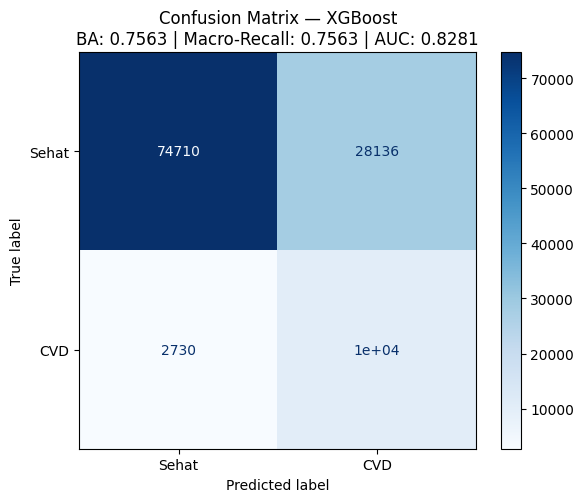


Top 20 Feature Importance:
   fitur  importance
_RFHYPE6    0.219507
_AGEG5YR    0.196184
 GENHLTH    0.187122
DIFFWALK    0.100073
    _SEX    0.062554
SMOKE100    0.041604
DIABETE4    0.036378
_CHOLCH3    0.017462
PHYSHLTH    0.015853
 INCOME3    0.015711
MEDCOST1    0.014831
_DRNKWK1    0.013543
   EDUCA    0.012474
_BMI5CAT    0.011555
_TOTINDA    0.011554
MENTHLTH    0.011502
_HLTHPLN    0.010968
_FRTLT1A    0.010821
_VEGLT1A    0.010304


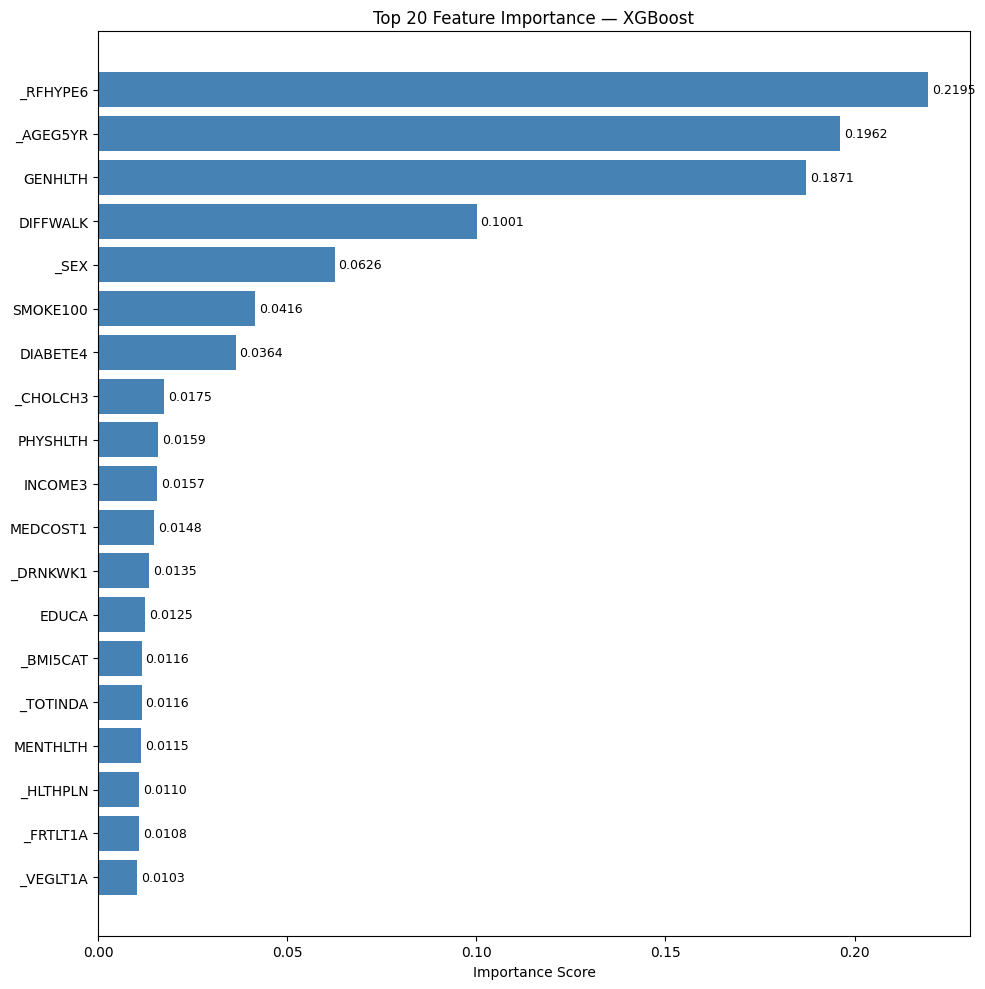

In [ ]:
# ── CARA PAKAI ────────────────────────────────────────────────────────────────
results = train_evaluate_xgb(X_train, X_test, y_train, y_test)

Class distribution → Sehat: 239972, CVD: 29801
     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.7563  ← METRIC UTAMA
  Macro-Recall       : 0.7563  ← METRIC UTAMA
  AUC-ROC            : 0.8281
-------------------------------------------------------
  F1-Score Macro     : 0.6115
  F1-Score Weighted  : 0.7808
  F1-Score CVD       : 0.3942
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7863
  Specificity (Sehat) : 0.7264

  TP: 10042 | TN: 74710 | FP: 28136 ← False Alarm | FN: 2730 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.96      0.73      0.83    102846
     CVD (1)       0.26      0.79      0.39     12772

    accuracy                           0.73    115618
   macro avg       0.61      0.76      0.61    115618
weighted avg       0.89      0.73      0.78    115618



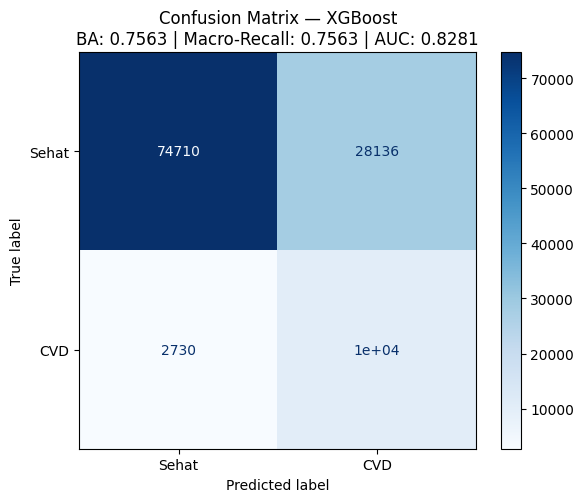


Top 20 Feature Importance:
   fitur  importance
_RFHYPE6    0.219507
_AGEG5YR    0.196184
 GENHLTH    0.187122
DIFFWALK    0.100073
    _SEX    0.062554
SMOKE100    0.041604
DIABETE4    0.036378
_CHOLCH3    0.017462
PHYSHLTH    0.015853
 INCOME3    0.015711
MEDCOST1    0.014831
_DRNKWK1    0.013543
   EDUCA    0.012474
_BMI5CAT    0.011555
_TOTINDA    0.011554
MENTHLTH    0.011502
_HLTHPLN    0.010968
_FRTLT1A    0.010821
_VEGLT1A    0.010304


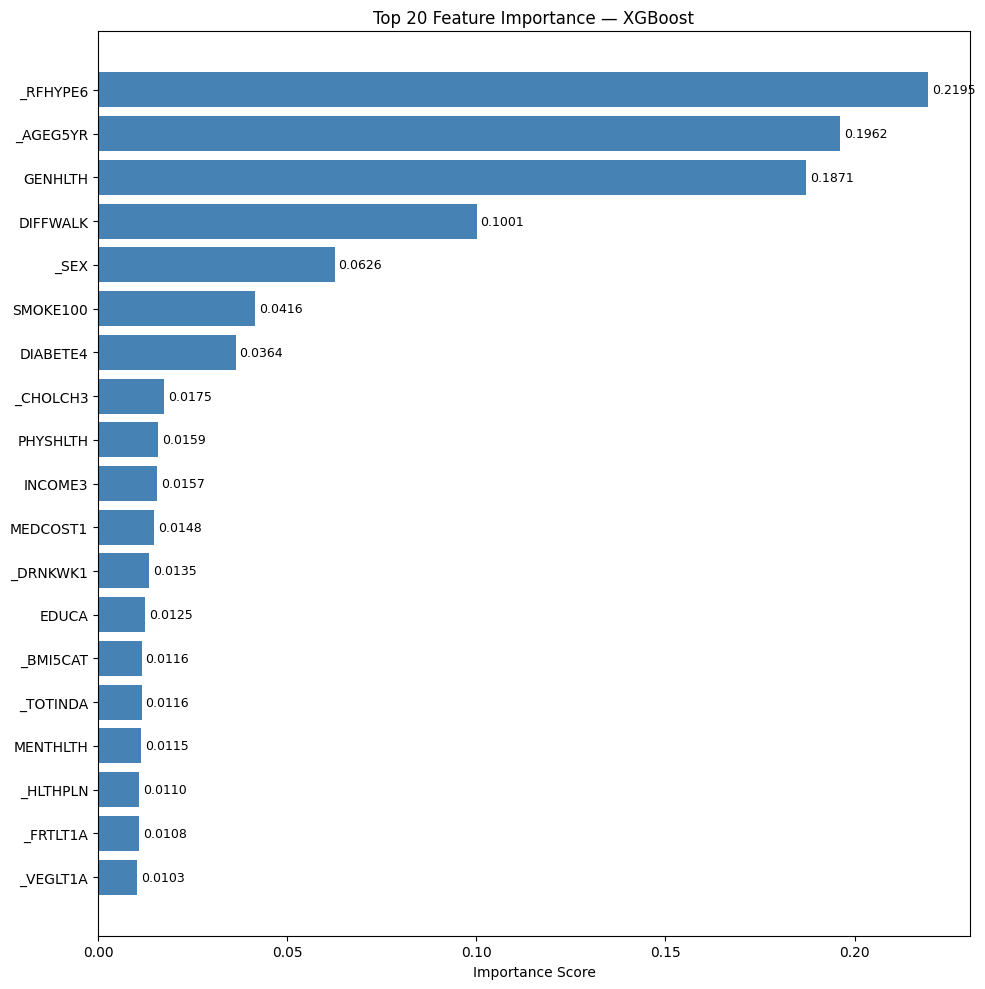

In [ ]:
# ── SEKARANG bisa langsung pakai function ─────────────────────────────────────
results = train_evaluate_xgb(X_train_scaled, X_test_scaled, y_train, y_test)